In [1]:
import torchvision.datasets as datasets
from torch.utils.data import TensorDataset, DataLoader
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import torch.nn as nn

# functions to use later

In [2]:
# Segmoid activation function
def sigmoid(z):
    return 1 / (1 + torch.exp(-z))
# Predection calculation
def predict(X):
    global W,b
    return sigmoid(X @ W + b)
# Cross Entropy loss function
def binary_cross_entropy(y_hat, y):
    eps = 1e-8
    return -torch.mean(y * torch.log(y_hat + eps) + (1 - y) * torch.log(1 - y_hat + eps))
# Gradient Descent Application function
def gradient_descent(train_loader, alpha=0.01, epochs=100):
    global W,b
    for epoch in range(epochs):
        total_loss = 0.0

        for X_batch, y_batch in train_loader_binary:
            y_batch = y_batch.view(-1, 1).float()
            X_batch = X_batch.view(X_batch.size(0), -1)

            y_hat = predict(X_batch)
            loss = binary_cross_entropy(y_hat, y_batch)
            with torch.no_grad():
                W -= alpha * (X_batch.T @ (y_hat - y_batch)) / X_batch.size(0)
                b -= alpha * torch.mean(y_hat - y_batch)

# Downloading the dataset MNIST for train and test

In [3]:
dataset = datasets.MNIST(root='./data', train=True, download=True)
X = dataset.data.numpy()
y = dataset.targets.numpy()
# Normalization
X = X / 255.0
# Flattening
X_flat = X.reshape(-1, 28*28)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.86MB/s]


# Split dataset

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_flat, y, test_size=0.4, stratify=y, random_state=3
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=3
)

# Preproccessing data

In [5]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

# batching the data
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)


# Logistic Regression Implementation
## Binary Classification

### Take only zero and one digits to classify on them

In [6]:
train_mask = (y_train_t == 0) | (y_train_t == 1)
val_mask   = (y_val_t == 0)   | (y_val_t == 1)
test_mask  = (y_test_t == 0)  | (y_test_t == 1)

train_dataset_binary = TensorDataset(X_train_t[train_mask],y_train_t[train_mask])
val_dataset_binary   = TensorDataset(X_val_t[val_mask], y_val_t[val_mask])
test_dataset_binary  = TensorDataset(X_test_t[test_mask], y_test_t[test_mask])

train_loader_binary = DataLoader(train_dataset_binary, batch_size=64, shuffle=True)
val_loader_binary   = DataLoader(val_dataset_binary, batch_size=64, shuffle=False)
test_loader_binary  = DataLoader(test_dataset_binary, batch_size=64, shuffle=False)

input_dim = 784

## change in valatain(loss,accuracy) and  valatain(loss,accuracy) 

In [7]:
W = torch.randn(input_dim, 1) 
b = torch.zeros(1)
val_losses=[]
val_acury=[]
train_losses=[]
trian_acury=[]

for epoch in range(60):
    gradient_descent(train_loader_binary,0.01,1)
    # 
    all_preds = []
    all_labels = []
    total_loss=0
    with torch.no_grad():
        for X_batch, y_batch in val_loader_binary:
            X_batch = X_batch.view(X_batch.size(0), -1)
            y_batch= y_batch.view(-1, 1).float()
            
            y_pred = predict(X_batch)
            
            loss = binary_cross_entropy(y_pred, y_batch)
            total_loss += loss.item()
            
            preds = (y_pred >= 0.5).int()
            all_preds.append(preds)
            all_labels.append(y_batch.int())
    
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    
    avg_loss_val = total_loss / len(val_loader_binary)
    accuracy_val = (all_preds.flatten() == all_labels.flatten()).float().mean()

    val_losses.append(avg_loss_val)
    val_acury.append(accuracy_val)

    # print(f"Validation Loss: {avg_loss_val:.4f}") 
    # print(f"Validation Accuracy: {accuracy_val.item() * 100:.2f}%")

    # 
    all_preds = []
    all_labels = []
    total_loss=0

    for X_batch, y_batch in train_loader_binary:
        X_batch = X_batch.view(X_batch.size(0), -1)
        y_batch= y_batch.view(-1, 1).float()
        
        y_pred = predict(X_batch)
        
        loss = binary_cross_entropy(y_pred, y_batch)
        total_loss += loss.item()
        
        preds = (y_pred >= 0.5).int()
        all_preds.append(preds)
        all_labels.append(y_batch.int())
    
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    
    avg_loss_train = total_loss / len(train_loader_binary)
    accuracy_train = (all_preds.flatten() == all_labels.flatten()).float().mean()

    train_losses.append(avg_loss_train)
    trian_acury.append(accuracy_train)

    # print(f"Train Loss: {avg_loss_train:.4f}")
    # print(f"Train Accuracy: {accuracy_train.item() * 100:.2f}%")


## Training and validation loss curves


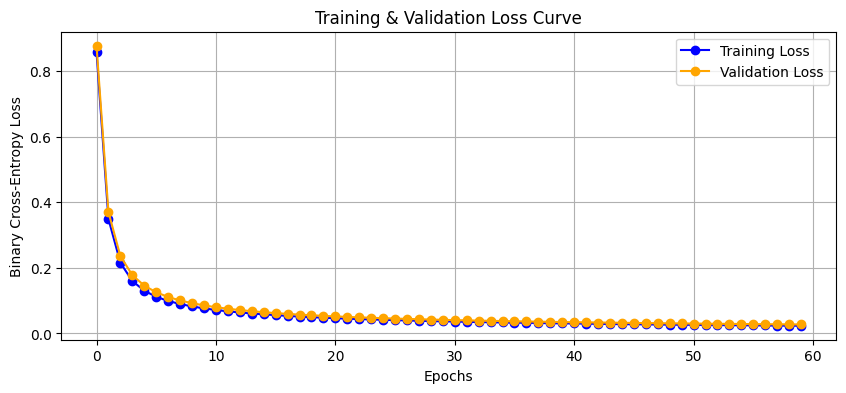

In [8]:
plt.figure(figsize=(10,4))
plt.plot( train_losses, label='Training Loss', color='blue', marker='o')
plt.plot( val_losses, label='Validation Loss', color='orange', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training & Validation Loss Curve') 
plt.legend()
plt.grid(True)
plt.show()

## Training and validation accuracy curves

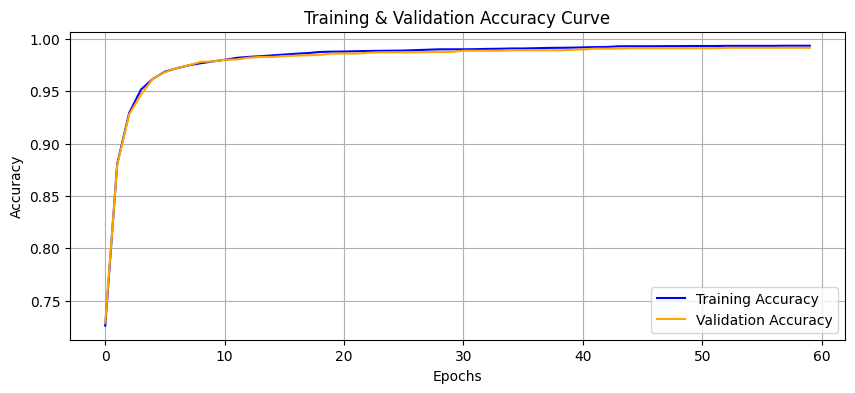

In [9]:
plt.figure(figsize=(10,4))
plt.plot(trian_acury, label='Training Accuracy', color='blue')
plt.plot(val_acury, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()

## Final test accuracy and confusion matrix


In [10]:
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_binary:
        X_batch = X_batch.view(X_batch.size(0), -1)
        y_batch= y_batch.view(-1, 1).float()
        
        y_pred = predict(X_batch)
        
        preds = (y_pred >= 0.5).int()
        all_preds.append(preds)
        all_labels.append(y_batch)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

test_accuracy = (all_preds.flatten() == all_labels.flatten().float()).float().mean()
print(f"Test Accuracy: {test_accuracy.item() * 100:.2f}%")

Test Accuracy: 98.90%


In [11]:
cm = confusion_matrix(all_labels.flatten().numpy(), all_preds.flatten().numpy())
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1165   20]
 [   8 1341]]


# Softmax Regression Implementation

In [12]:

def softmax(z):
    exp_z = torch.exp(z - torch.max(z, dim=1, keepdim=True)[0]) 
    return exp_z / torch.sum(exp_z, dim=1, keepdim=True)

def predict_soft(X):
    global W,b
    return softmax(X @ W + b)
    
#Cross Entropy Loss
def cross_entropy_soft(y_hat, y):
    eps = 1e-8
    y_one_hot = torch.zeros_like(y_hat)
    y_one_hot[torch.arange(y.size(0)), y] = 1
    return -torch.mean(torch.sum(y_one_hot * torch.log(y_hat + eps), dim=1))
# gradient descent for softmax
def gradient_descent_softmax(train_loader, alpha=0.01, epochs=1):
    global W, b
    for i in range(epochs):    
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.view(X_batch.size(0), -1)
            y_batch = y_batch.view(-1)
            
            y_hat = predict_soft(X_batch)
            y_one_hot = torch.zeros_like(y_hat)
            y_one_hot[torch.arange(y_batch.size(0)), y_batch] = 1
            
            grad_W = X_batch.T @ (y_hat - y_one_hot) / X_batch.size(0)
            grad_b = torch.mean(y_hat - y_one_hot, dim=0)
            
            with torch.no_grad():
                W -= alpha * grad_W
                b -= alpha * grad_b

    

# built-in implementations to softmax

In [13]:
class SoftmaxBuiltIn(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)
    
    def forward(self, x):
        return self.linear(x)

input_dim = X_train_t.shape[1]
num_classes = 10
model = SoftmaxBuiltIn(input_dim, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# losses and accuracy for validation and train data by softmax

In [14]:
num_classes = 10
input_dim = X_train_t.shape[1]

W = torch.randn(input_dim,num_classes)
b = torch.zeros(num_classes)
val_losses=[]
val_acury=[]
train_losses=[]
trian_acury=[]
all_preds_train = []
all_preds_val = []
all_labels_train = []
all_labels_val = []
for epoch in range(60):
    gradient_descent_softmax(train_loader,0.01)
    # -------------------validaton-----------------
    all_preds = []
    all_labels = []
    total_loss=0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.view(X_batch.size(0), -1)
            y_batch = y_batch.view(-1).long()
            
            y_pred = predict_soft(X_batch)
            
            loss = cross_entropy_soft(y_pred, y_batch)
            total_loss += loss.item()
            
            preds = torch.argmax(y_pred, dim=1)
            all_preds.append(preds)
            all_labels.append(y_batch.long())
    
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    
    avg_loss_val = total_loss / len(val_loader)
    accuracy_val = (all_preds.flatten() == all_labels.flatten().float()).float().mean()

    val_losses.append(avg_loss_val)
    val_acury.append(accuracy_val)

    # print(f"Validation Loss: {avg_loss_val:.4f}") 
    # print(f"Validation Accuracy: {accuracy_val.item() * 100:.2f}%")
    all_preds_val = all_preds
    all_labels_val = all_labels
    # ---------------train---------------------
    all_preds = []
    all_labels = []
    total_loss=0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.view(X_batch.size(0), -1)
        y_batch = y_batch.view(-1).long()
        
        y_pred = predict_soft(X_batch)
        
        loss =cross_entropy_soft(y_pred, y_batch)
        total_loss += loss.item()
        
        preds = torch.argmax(y_pred, dim=1)
        all_preds.append(preds)
        all_labels.append(y_batch.long())
    
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    
    avg_loss_train = total_loss / len(train_loader)
    accuracy_train = (all_preds.flatten() == all_labels.flatten().float()).float().mean()

    train_losses.append(avg_loss_train)
    trian_acury.append(accuracy_train)

    all_preds_train = all_preds
    all_labels_train = all_labels
    # print(f"Train Loss: {avg_loss_train:.4f}")
    # print(f"Train Accuracy: {accuracy_train.item() * 100:.2f}%")


In [15]:
cm = confusion_matrix(all_labels_val.flatten().numpy(), all_preds_val.flatten().numpy())

print("\nConfusion Matrix for validation:\n", cm)

per_class_acc = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class Accuracy for validation:")
for i, acc in enumerate(per_class_acc):
    print(f"Class {i}: {acc*100:.2f}%")
    
cm = confusion_matrix(all_labels_train.flatten().numpy(), all_preds_train.flatten().numpy())

print("\nConfusion Matrix for train:\n", cm)

per_class_acc = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class Accuracy for train:")
for i, acc in enumerate(per_class_acc):
    print(f"Class {i}: {acc*100:.2f}%")


Confusion Matrix for validation:
 [[1098    0   12   10    2   21   18    5   13    5]
 [   0 1260    7   11    1    6    1    4   54    4]
 [  13   12  985   45   26    8   37   20   36    9]
 [   8    4   33 1038    1   65    9   13   35   21]
 [   2    6   13   10  997    6   15   12   24   84]
 [  35    8   13   70   15  809   20   13   70   31]
 [  13    6   28    2   14   21 1075    3   19    3]
 [   5   13   27   15   22    9    0 1091    8   63]
 [  12   35   32   64   12   58   15    9  903   30]
 [   6   10    6   29   88   10    4   64   28  945]]

Per-class Accuracy for validation:
Class 0: 92.74%
Class 1: 93.47%
Class 2: 82.70%
Class 3: 84.60%
Class 4: 85.29%
Class 5: 74.63%
Class 6: 90.79%
Class 7: 87.07%
Class 8: 77.18%
Class 9: 79.41%

Confusion Matrix for train:
 [[3327    0   26   20    5   83   32   13   37   11]
 [   2 3823   34   38    5   24    6   12   94    7]
 [  49   47 2992   90   56   29  108   62  117   25]
 [  16   20  118 3082    5  172   32   51  114   

# losses and accuracy to vaildation data by built in softmax

In [16]:
train_losses_built, val_losses_built = [], []
train_acc_built, val_acc_built = [], []

for epoch in range(60):
    #  ---------------train---------------------
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.view(X_batch.size(0), -1)
        y_batch = y_batch.view(-1).long()
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        all_preds.append(torch.argmax(logits, dim=1))
        all_labels.append(y_batch)
    
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    train_losses_built.append(total_loss / len(train_loader))
    train_acc_built.append((all_preds.flatten() == all_labels.flatten().float()).float().mean().item())

    #  -------------------validaton-----------------
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.view(X_batch.size(0), -1)
            y_batch = y_batch.view(-1).long()
            
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item()
            
            all_preds.append(torch.argmax(logits, dim=1))
            all_labels.append(y_batch)
    
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    val_losses_built.append(total_loss / len(val_loader))
    val_acc_built.append((all_preds.flatten() == all_labels.flatten().float()).float().mean().item())


## Training and validation metrics plots

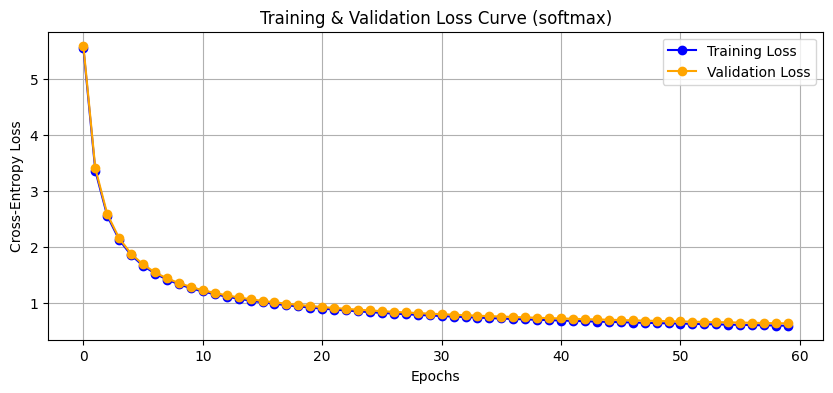

In [17]:
plt.figure(figsize=(10,4))
plt.plot( train_losses, label='Training Loss', color='blue', marker='o')
plt.plot( val_losses, label='Validation Loss', color='orange', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training & Validation Loss Curve (softmax)') 
plt.legend()
plt.grid(True)
plt.show()

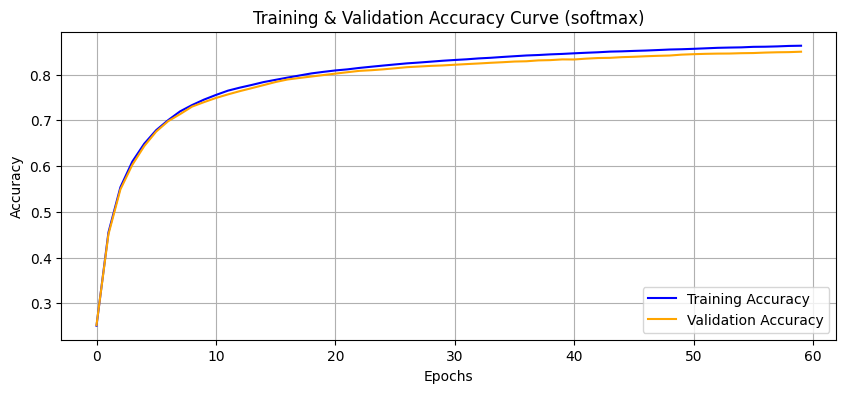

In [18]:
plt.figure(figsize=(10,4))
plt.plot(trian_acury, label='Training Accuracy', color='blue')
plt.plot(val_acury, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy Curve (softmax)')
plt.legend()
plt.grid(True)
plt.show()

## Compare with PyTorch's built-in implementations for verification


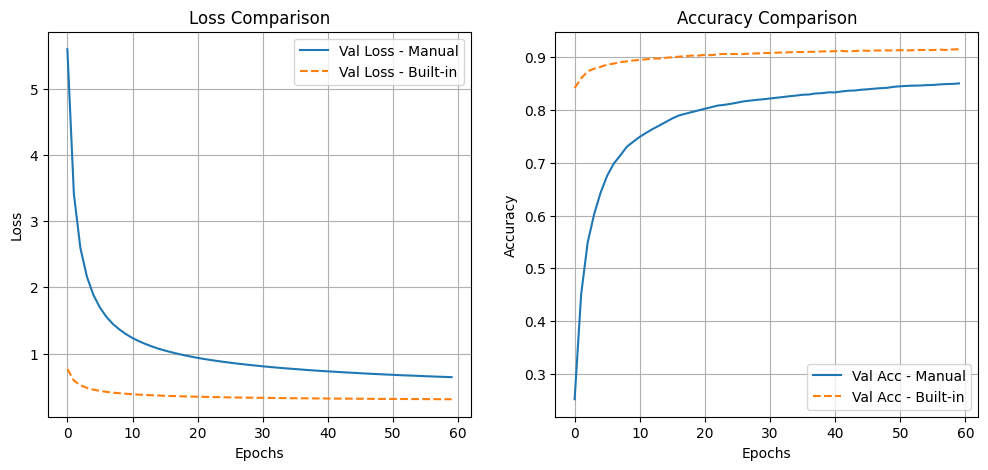

In [19]:
plt.figure(figsize=(12,5))

# Loss comparison
plt.subplot(1,2,1)
plt.plot(val_losses, label='Val Loss - Manual')
plt.plot(val_losses_built, label='Val Loss - Built-in', linestyle='--')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.title('Loss Comparison')

# Accuracy comparison
plt.subplot(1,2,2)
plt.plot(val_acury, label='Val Acc - Manual')
plt.plot(val_acc_built, label='Val Acc - Built-in', linestyle='--')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
plt.title('Accuracy Comparison')

plt.show()

## Test set evaluation with confusion matrix

In [20]:
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.view(X_batch.size(0), -1)
        y_batch= y_batch.view(-1, 1)
        
        y_pred = predict_soft(X_batch)
        
        preds = torch.argmax(y_pred, dim=1)
        all_preds.append(preds)
        all_labels.append(y_batch)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

test_accuracy = (all_preds.flatten()== all_labels.flatten().float()).float().mean()
print(f"Test Accuracy: {test_accuracy.item() * 100:.2f}%")

Test Accuracy: 85.44%


In [21]:
cm = confusion_matrix(all_labels.flatten().numpy(), all_preds.flatten().numpy())

print("\nConfusion Matrix:\n", cm)

per_class_acc = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class Accuracy:")
for i, acc in enumerate(per_class_acc):
    print(f"Class {i}: {acc*100:.2f}%")


Confusion Matrix:
 [[1103    0    7    6    4   33   16    2   12    2]
 [   1 1265   13   14    2    9    5    7   30    3]
 [  16   23  995   34   22    4   25   17   43   13]
 [  10    9   36 1002    6   76   13   22   27   25]
 [   1    4    7    4 1014    4   19   11   17   87]
 [  29    8   22   67   25  799   28    8   73   25]
 [  14    8   21    3   17   21 1083    0   14    2]
 [  10    9   26   16   15    8    4 1097    4   64]
 [   5   32   32   51    5   66    9   13  931   26]
 [   8    6    7   21   71   19    1   70   23  964]]

Per-class Accuracy:
Class 0: 93.08%
Class 1: 93.77%
Class 2: 83.47%
Class 3: 81.73%
Class 4: 86.82%
Class 5: 73.71%
Class 6: 91.55%
Class 7: 87.55%
Class 8: 79.57%
Class 9: 81.01%


# Comprehensive Analysis
## Logistic regression

### Learning rate

In [22]:
lr = [0.001, 0.01, 0.1, 1.0]
val_losses={str(l): [] for l in lr}
val_accuracy={str(l): [] for l in lr}
val_losses_lr =[]
val_accuracy_lr =[]
global W,b
for l in lr:
    W = torch.randn(input_dim, 1) 
    b = torch.zeros(1)
    val_losses_epochs = []
    val_accuracy_epochs = []
    avg_loss_val = 0
    accuracy_val = 0
    for epoch in range(60):
        gradient_descent(train_loader_binary,l ,1)
        # 
        all_preds = []
        all_labels = []
        total_loss=0
        with torch.no_grad():
            for X_batch, y_batch in val_loader_binary:
                X_batch = X_batch.view(X_batch.size(0), -1)
                y_batch= y_batch.view(-1, 1).float()
                
                y_pred = predict(X_batch)
                
                loss = binary_cross_entropy(y_pred, y_batch)
                total_loss += loss.item()
                
                preds = (y_pred >= 0.5).int()
                all_preds.append(preds)
                all_labels.append(y_batch.int())
        
        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)
        
        avg_loss_val = total_loss / len(val_loader_binary)
        accuracy_val = (all_preds.flatten() == all_labels.flatten()).float().mean()
    
        val_losses[f"{l}"].append(avg_loss_val)
        val_accuracy[f"{l}"].append(accuracy_val)
    val_losses_lr.append(avg_loss_val)
    val_accuracy_lr.append(accuracy_val)

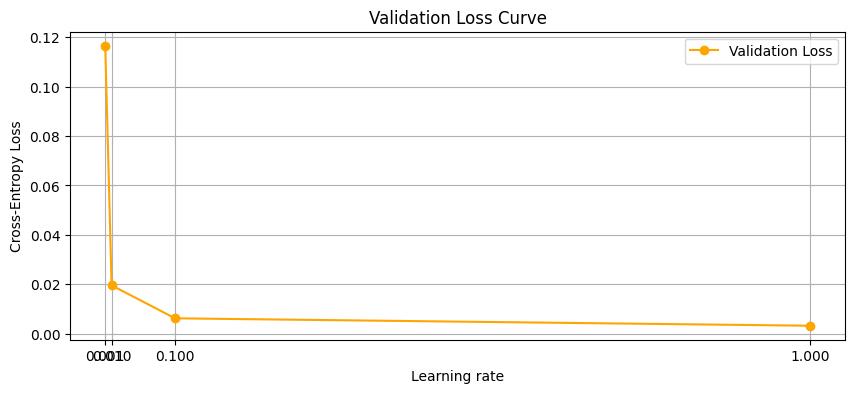

In [23]:
plt.figure(figsize=(10,4))
plt.plot(lr, val_losses_lr, label='Validation Loss', color='orange', marker='o')
plt.xlabel('Learning rate')
plt.ylabel('Cross-Entropy Loss')
plt.title('Validation Loss Curve') 
plt.legend()
plt.grid(True)
plt.xticks(lr)
plt.show()

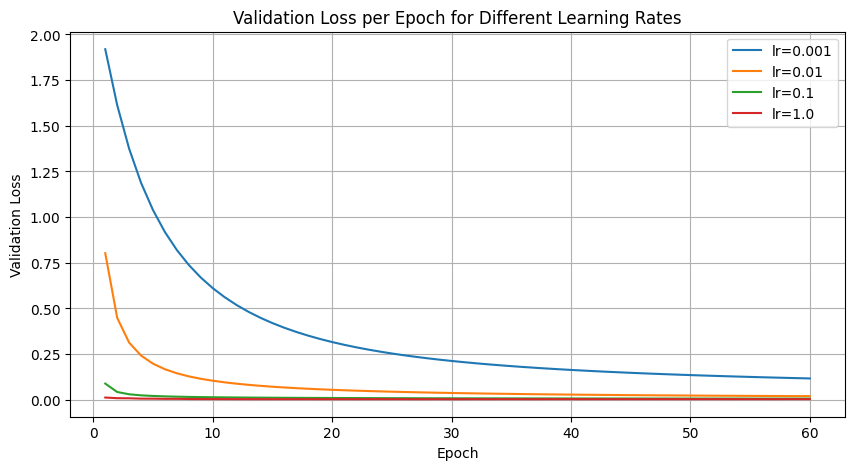

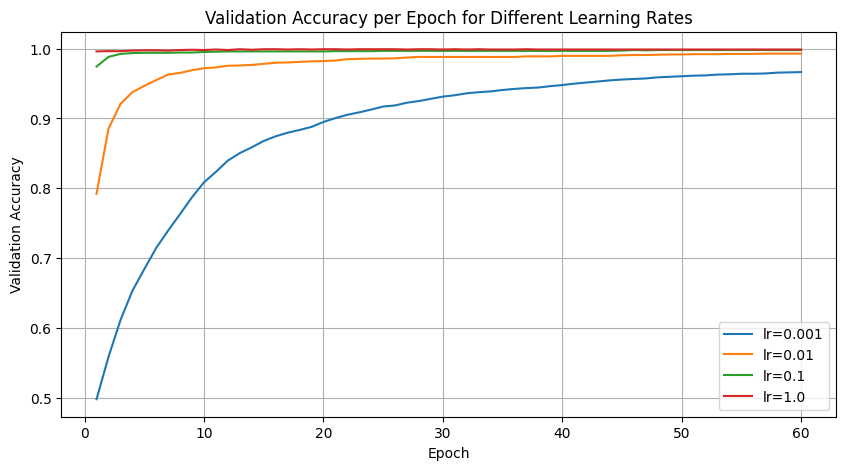

In [24]:
epochs = range(1, 61)
plt.figure(figsize=(10,5))
for l in lr:
    plt.plot(epochs, val_losses[f"{l}"], label=f"lr={l}")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss per Epoch for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

# Validation Accuracy
plt.figure(figsize=(10,5))
for l in lr:
    plt.plot(epochs, val_accuracy[f"{l}"], label=f"lr={l}")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy per Epoch for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

### We can see that the smaller learning rates take more epochs to converge and the largest ones took less time to reach somepoint where the  is zero so the weights stop changing
### And about stability smaller leargning rates are more stable than the larger (We can see that from graphs) and it's logical as smaller learning rates go to the saddle point step by step using a lower steps

### Batch Sizes

In [25]:
batches = [16,32,64,128]
val_losses_all={str(b): [] for b in batches}
val_accuracy_all={str(b): [] for b in batches}
global W,b
for batch in batches:
    train_loader_binary_batched = DataLoader(train_dataset_binary, batch_size=batch, shuffle=True)
    val_loader_binary_batched   = DataLoader(val_dataset_binary, batch_size=batch, shuffle=False)
    test_loader_binary_batched  = DataLoader(test_dataset_binary, batch_size=batch, shuffle=False)
    W = torch.randn(input_dim, 1) 
    b = torch.zeros(1)
    val_losses=[]
    val_acury=[]
    train_losses=[]
    trian_acury=[]
    
    for epoch in range(60):
        gradient_descent(train_loader_binary_batched,0.01,1)
        # 
        all_preds = []
        all_labels = []
        total_loss=0
        with torch.no_grad():
            for X_batch, y_batch in val_loader_binary_batched:
                X_batch = X_batch.view(X_batch.size(0), -1)
                y_batch= y_batch.view(-1, 1).float()
                
                y_pred = predict(X_batch)
                
                loss = binary_cross_entropy(y_pred, y_batch)
                total_loss += loss.item()
                
                preds = (y_pred >= 0.5).int()
                all_preds.append(preds)
                all_labels.append(y_batch.int())
        
        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)
        
        avg_loss_val = total_loss / len(val_loader_binary)
        accuracy_val = (all_preds.flatten() == all_labels.flatten()).float().mean()
    
        val_losses.append(avg_loss_val)
        val_acury.append(accuracy_val)
    val_losses_all[f"{batch}"] = val_losses
    val_accuracy_all[f"{batch}"] = val_acury

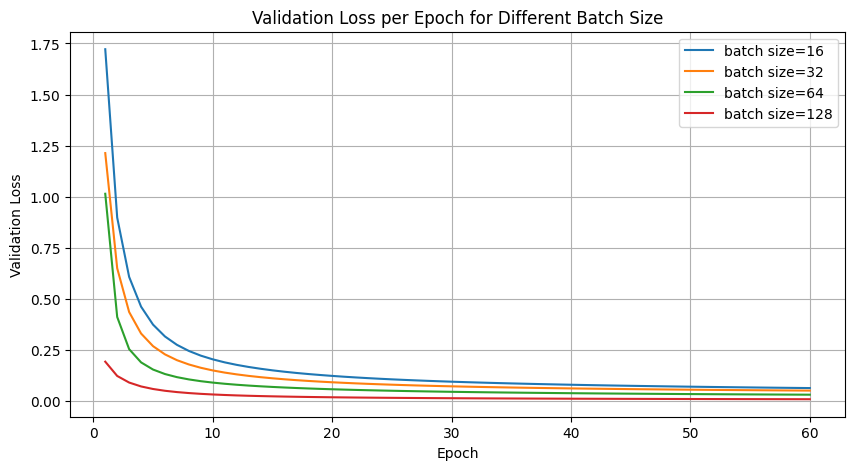

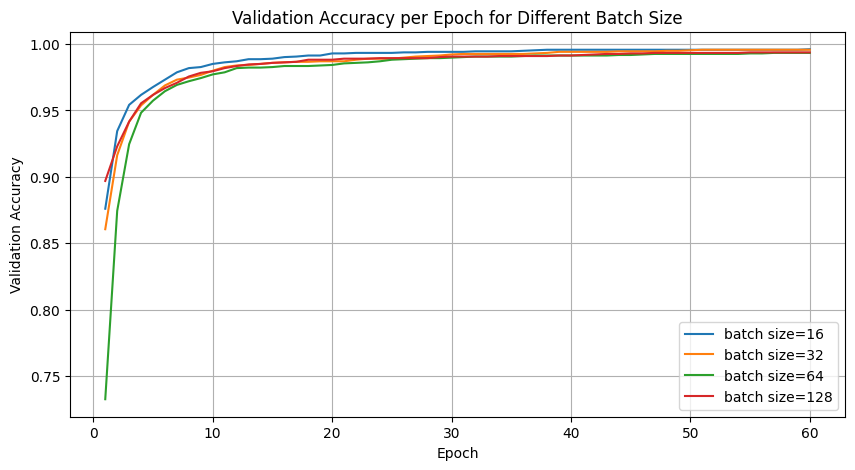

In [26]:
epochs = range(1, 61)
plt.figure(figsize=(10,5))
for batch in batches:
    plt.plot(epochs, val_losses_all[f"{batch}"], label=f"batch size={batch}")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss per Epoch for Different Batch Size")
plt.legend()
plt.grid(True)
plt.show()

# Validation Accuracy
plt.figure(figsize=(10,5))
for batch in batches:
    plt.plot(epochs, val_accuracy_all[f"{batch}"], label=f"batch size={batch}")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy per Epoch for Different Batch Size")
plt.legend()
plt.grid(True)
plt.show()

### Here we notice that smaller batch sizes are more stable as it takes into account smaller data and checks on them but it's slower than the larger ones so it's better to use somevalue in the middle so we used 64 batch size

## Softmax

In [27]:
lrs = [0.001, 0.01, 0.1, 1.0]
num_epochs = 60

val_losses_softmax = {str(lr): [] for lr in lrs}
val_accuracy_softmax = {str(lr): [] for lr in lrs}
for l in lrs:
    # print(f"\n--- Training with learning rate = {lr} ---")
    model = SoftmaxBuiltIn(input_dim, num_classes)
    optimizer = torch.optim.SGD(model.parameters(), lr=l)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        #train
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.view(X_batch.size(0), -1)
            y_batch = y_batch.long()

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

        # validation
        model.eval()
        total_val_loss = 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.view(X_batch.size(0), -1)
                y_batch = y_batch.long()
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                total_val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                all_preds.append(preds)
                all_labels.append(y_batch)

        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)
        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = (all_preds.flatten() == all_labels.flatten().float()).float().mean().item()

        val_losses_softmax[str(l)].append(avg_val_loss)
        val_accuracy_softmax[str(l)].append(val_acc)

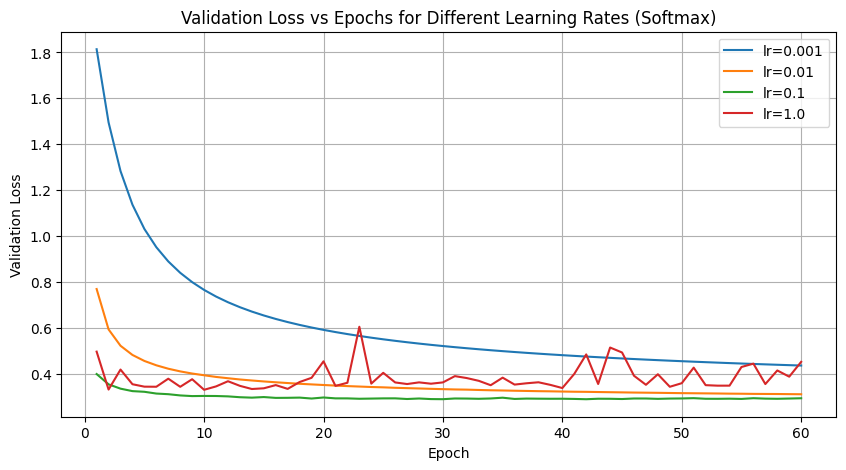

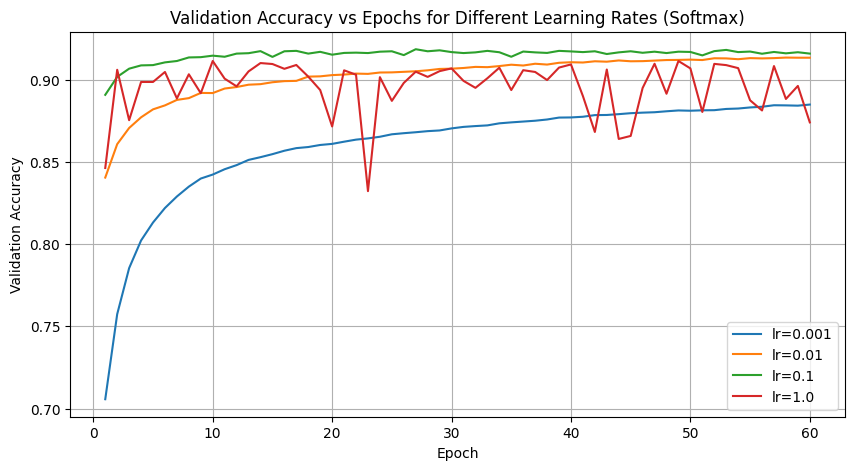

In [28]:
plt.figure(figsize=(10,5))
for lr in lrs:
    plt.plot(range(1, num_epochs+1), val_losses_softmax[str(lr)], label=f'lr={lr}')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss vs Epochs for Different Learning Rates (Softmax)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
for lr in lrs:
    plt.plot(range(1, num_epochs+1), val_accuracy_softmax[str(lr)], label=f'lr={lr}')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs Epochs for Different Learning Rates (Softmax)')
plt.legend()
plt.grid(True)
plt.show()

## We can see that using smaller learning rate is much more stable than the large ones obviously from the graph when `lr = 1` it's not stable as it jumps in the function trying to reach the minimum but always going after it, but the very small ones take to much time to reach the global minima, so it's better to use `lr = 0.01`.

In [29]:
batches = [16, 32, 64, 128]
num_epochs = 60
l = 0.001
val_losses_all = {str(b): [] for b in batches}
val_accuracy_all = {str(b): [] for b in batches}

for batch in batches:
    train_loader_batched = DataLoader(train_dataset, batch_size=batch, shuffle=True)
    val_loader_batched = DataLoader(val_dataset, batch_size=batch, shuffle=False)

    model = SoftmaxBuiltIn(input_dim=784, num_classes=10)
    optimizer = torch.optim.SGD(model.parameters(), lr=l)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        # train
        model.train()
        for X_batch, y_batch in train_loader_batched:
            X_batch = X_batch.view(X_batch.size(0), -1)
            y_batch = y_batch.long()

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

        # validation
        model.eval()
        total_val_loss = 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for X_batch, y_batch in val_loader_batched:
                X_batch = X_batch.view(X_batch.size(0), -1)
                y_batch = y_batch.long()
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                total_val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                all_preds.append(preds)
                all_labels.append(y_batch)

        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)
        avg_val_loss = total_val_loss / len(val_loader_batched)
        val_acc = (all_preds.flatten() == all_labels.flatten().float()).float().mean().item()

        val_losses_all[str(batch)].append(avg_val_loss)
        val_accuracy_all[str(batch)].append(val_acc)

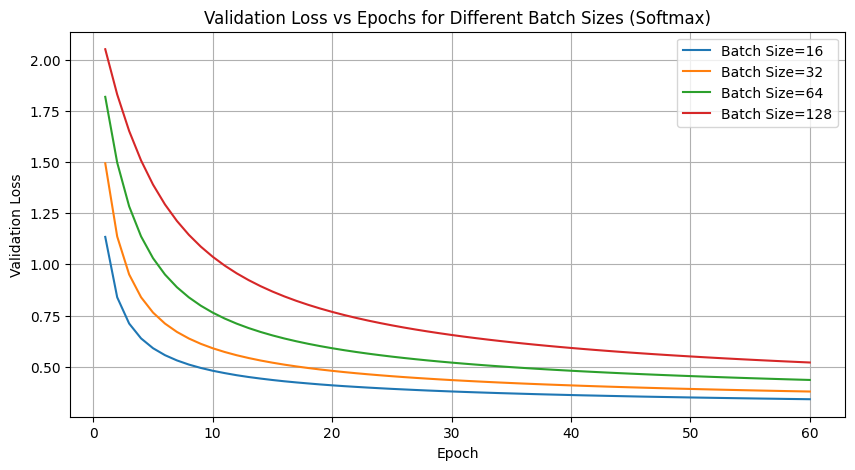

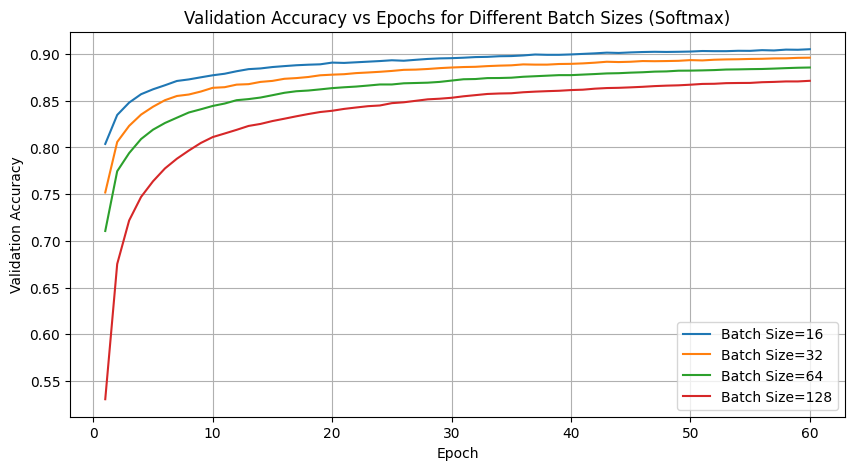

In [30]:
plt.figure(figsize=(10,5))
for batch in batches:
    plt.plot(range(1, num_epochs+1), val_losses_all[str(batch)], label=f'Batch Size={batch}')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss vs Epochs for Different Batch Sizes (Softmax)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
for batch in batches:
    plt.plot(range(1, num_epochs+1), val_accuracy_all[str(batch)], label=f'Batch Size={batch}')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs Epochs for Different Batch Sizes (Softmax)')
plt.legend()
plt.grid(True)
plt.show()

## As expected, using smaller batch sizes made the training slower, since the model updates its weights more frequently with each mini batch. However, it often led to slightly better accuracy, as the noisier gradient updates help the model generalize better to unseen data.